# YOLO-World-S Backbone-Swap Benchmark — Analysis & Comparison

**What this notebook does.** It loads every training/evaluation artifact produced by the backbone-swap
pipeline (`logs/`, `work_dirs/*/vis_data/scalars.json`, `results/*.json`) and turns them into a single,
readable comparison: summary tables, accuracy curves, accuracy-vs-cost trade-offs, training dynamics,
and a written explanation of **why** each backbone landed where it did.

## The experiment in one paragraph
[YOLO-World](https://github.com/AILab-CVC/YOLO-World) is an open-vocabulary detector whose **vision
backbone is YOLOv8**. This study keeps *everything* fixed — the CLIP text branch, the text-guided
`YOLOWorldPAFPN` neck, the `YOLOWorldHead`, the AdamW recipe, and the COCO data pipeline — and swaps
**only the vision backbone** through six YOLO generations: `yolov8s` (baseline), `yolov9s`, `yolov10s`,
`yolo11s`, `yolo12s`, `yolo26s`. Because the backbone is the *only* variable, any difference in COCO
mAP, params, FLOPs, or FPS is attributable to the backbone itself.

## Training protocol (screen → promote)
Training all six to 80 epochs is ~6 GPU-days on one A100, so a funnel was used:

1. **Baseline** `yolov8s` is trained the full **80 epochs** (reference recipe).
2. **Screen (40e):** every other backbone is trained for **40 epochs** that are an *exact prefix* of the
   80-epoch schedule (only `train_cfg.max_epochs` is capped to 40; the LR curve, mosaic, and
   augmentations for epochs 1-40 are identical to the baseline). This makes **`mAP@40`** directly
   comparable across variants.
3. **Promote (40->80):** any backbone whose `mAP@40` is within a small margin (0.005) of the baseline's
   `mAP@40` is **resumed** from its epoch-40 checkpoint to the full 80 epochs. Losers are dropped.

> **Read this first - what \"done\" means here.** `yolov9s` was *screened only* (dropped at 40e, so its
> curves stop at epoch 40). The other five reach epoch 80. `mAP@40` is the screening number; `best mAP`
> is the full-run number. All numbers are COCO `val2017` **bbox** mAP from `mmdet.CocoMetric`.

## Notebook layout
1. Setup & data loading  -  2. The six backbones  -  3. Headline results table  -  4. Metric glossary  -
5. Accuracy over training  -  6. Accuracy-vs-cost trade-offs  -  7. Training dynamics  -
8. Why these outcomes happened  -  9. Conclusions & recommendations

## 1. Setup &amp; data loading

We read three kinds of artifacts, all already on disk:

| source | what it gives us |
|---|---|
| `results/map_results.json` | clean per-epoch COCO val mAP (mAP, AP50, AP75, AP-small/medium/large) for all 6 backbones, plus `best`/`@40` summaries |
| `results/benchmark_speed.json` | params (vision + full), GFLOPs@640, and fp16/fp32 latency &amp; FPS measured on the A100 |
| `work_dirs/<model>/<ts>/vis_data/scalars.json` | raw per-iteration training scalars: total loss + `cls`/`bbox`/`dfl` components, LR, grad-norm, GPU memory, sec/iter |

For promoted backbones there are **two** `scalars.json` runs (the 40e screen + the 40→80 resume); we read
both and order by `epoch`, so the training curves are continuous across the full schedule.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.float_format", lambda v: f"{v:.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.axisbelow": True, "font.size": 11})


def find_root() -> Path:
    """Locate the yolo_world_test root regardless of where the kernel runs."""
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "results" / "map_results.json").exists():
            return p
    fallback = Path.home() / "yolo_world_test"
    if (fallback / "results" / "map_results.json").exists():
        return fallback
    raise FileNotFoundError("Could not locate yolo_world_test root (results/map_results.json)")


ROOT = find_root()
FIGDIR = ROOT / "results" / "analysis" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

mr = json.loads((ROOT / "results" / "map_results.json").read_text())
SUMMARY = mr["summary"]
SPEED = mr["speed"]
BASELINE = mr["baseline"]

# Fixed display order = chronological YOLO generations.
MODELS = ["yolov8s", "yolov9s", "yolov10s", "yolo11s", "yolo12s", "yolo26s"]

# Consistent colour/marker per backbone (baseline is dashed grey).
STYLE = {
    "yolov8s":  dict(color="#444444", ls="--", marker="o"),
    "yolov9s":  dict(color="#9467bd", ls="-",  marker="v"),
    "yolov10s": dict(color="#1f77b4", ls="-",  marker="s"),
    "yolo11s":  dict(color="#ff7f0e", ls="-",  marker="D"),
    "yolo12s":  dict(color="#2ca02c", ls="-",  marker="^"),
    "yolo26s":  dict(color="#d62728", ls="-",  marker="P"),
}


def savefig(fig, name):
    fig.savefig(FIGDIR / name, dpi=130, bbox_inches="tight")


print(f"ROOT        = {str(ROOT).replace(str(Path.home()), '~')}")
print(f"baseline    = {BASELINE}")
print(f"models      = {MODELS}")
print(f"figures ->    {FIGDIR.relative_to(ROOT)}")

ROOT        = ~/yolo_world_test
baseline    = yolov8s
models      = ['yolov8s', 'yolov9s', 'yolov10s', 'yolo11s', 'yolo12s', 'yolo26s']
figures ->    results/analysis/figures


In [2]:
# ---- validation metrics (clean, per-epoch) from results/map_results.json ----
def val_df(model: str) -> pd.DataFrame:
    """Per-epoch COCO val metrics, indexed by epoch."""
    return pd.DataFrame(SUMMARY[model]["points"]).set_index("epoch").sort_index()


def best_point(model: str) -> dict:
    """The val record at the model's best epoch (used for size-breakdown bars)."""
    be = SUMMARY[model]["best_epoch"]
    for p in SUMMARY[model]["points"]:
        if p["epoch"] == be:
            return p
    return SUMMARY[model]["points"][-1]


# ---- raw training scalars from work_dirs/<model>/<ts>/vis_data/scalars.json ----
def _load_scalar_lines(model: str):
    """Return (train_records, val_records) merged across all runs of a model."""
    train, val = [], []
    wd = ROOT / "work_dirs" / model
    for vis in sorted(wd.glob("2026*/vis_data/scalars.json")):
        for line in vis.read_text().splitlines():
            line = line.strip()
            if not line:
                continue
            d = json.loads(line)          # json.loads accepts the literal Infinity
            if "coco/bbox_mAP" in d:
                val.append(d)
            elif "loss" in d:
                train.append(d)
    return train, val


def train_epoch_df(model: str) -> pd.DataFrame:
    """Aggregate the per-iteration training log to one row per epoch."""
    train, _ = _load_scalar_lines(model)
    if not train:
        return pd.DataFrame()
    df = pd.DataFrame(train)
    df["grad_norm"] = (pd.to_numeric(df["grad_norm"], errors="coerce")
                         .replace([np.inf, -np.inf], np.nan))
    g = df.groupby("epoch")
    out = pd.DataFrame({
        "loss":       g["loss"].mean(),
        "loss_cls":   g["loss_cls"].mean(),
        "loss_bbox":  g["loss_bbox"].mean(),
        "loss_dfl":   g["loss_dfl"].mean(),
        "lr":         g["lr"].last(),
        "grad_norm":  g["grad_norm"].mean(),
        "sec_per_iter": g["time"].mean(),
        "mem_MB":     g["memory"].max(),
        "logged_iters": g.size(),
    })
    return out.sort_index()


# Pre-load training curves once (a few seconds: ~6 MB of JSONL per promoted model).
TRAIN = {m: train_epoch_df(m) for m in MODELS}
for m in MODELS:
    n = len(TRAIN[m])
    print(f"{m:9s}: {n:2d} training epochs parsed, "
          f"val points {len(SUMMARY[m]['points']):2d}, "
          f"best mAP {SUMMARY[m]['best_mAP']:.3f} @ ep {SUMMARY[m]['best_epoch']}")

yolov8s  : 80 training epochs parsed, val points 25, best mAP 0.428 @ ep 69
yolov9s  : 40 training epochs parsed, val points  8, best mAP 0.415 @ ep 40
yolov10s : 80 training epochs parsed, val points 25, best mAP 0.448 @ ep 65
yolo11s  : 80 training epochs parsed, val points 25, best mAP 0.458 @ ep 69
yolo12s  : 80 training epochs parsed, val points 25, best mAP 0.470 @ ep 71
yolo26s  : 80 training epochs parsed, val points 25, best mAP 0.469 @ ep 77


## 2. The six backbones &amp; the shared recipe

Only the **image backbone** differs. The adapter (`UltralyticsYOLOBackbone`) instantiates each Ultralytics
architecture from its COCO-pretrained `.pt`, keeps only the backbone, and taps the P3/P4/P5 feature maps
(strides 8/16/32). The neck/head channel widths track each backbone's P3/P4/P5 output channels — that is
the *only* structural thing that changes downstream.

**Held identical across all variants** (from the auto-generated configs):

- **Neck:** `YOLOWorldPAFPN`, text-guided, `embed_channels=[64,128,256]`, `num_heads=[2,4,8]`, `MaxSigmoidCSPLayerWithTwoConv`.
- **Head:** `YOLOWorldHead` (contrastive, `embed_dims=512`), 80 COCO classes.
- **Text encoder:** frozen CLIP ViT-B/32 (`63.4 M` params, identical for everyone; `lr_mult=0.01`).
- **Optimiser:** AdamW, `base_lr=2e-4`, `weight_decay=0.05`, `YOLOWv5OptimizerConstructor`, EMA.
- **Data/recipe:** COCO 2017, 640×640, mask-refine **mosaic + copy-paste(0.3) + mixup(0.15)** + `RandomLoadText`, batch 16, **close-mosaic for the last 10 epochs** (pipeline switch at epoch 70), AMP.
- **Eval:** COCO `val2017`, `mmdet.CocoMetric`, `bbox`.

In [3]:
# Short architecture notes (context for the discussion; not measured here).
ARCH_NOTES = {
    "yolov8s":  "CSPDarknet + C2f (baseline; YOLO-World's native backbone)",
    "yolov9s":  "GELAN + PGI; narrowest P4/P5 (192/256), fewest params/FLOPs",
    "yolov10s": "CSPDarknet + C2fCIB, NMS-free design; efficient",
    "yolo11s":  "C3k2 + C2PSA attention; wider P3 (256)",
    "yolo12s":  "Area-Attention (A2C2f) centric; heaviest FLOPs",
    "yolo26s":  "C3k2 + attention, latency-tuned; attention without the FLOP blow-up",
}

rows = []
for m in MODELS:
    sp = SPEED[m]
    rows.append({
        "backbone": m,
        "P3/P4/P5": str(sp["channels"]),
        "params_vision_M": sp["params_vision_M"],
        "params_full_M": sp["params_full_M"],
        "GFLOPs@640": sp["gflops_vision"],
        "architecture": ARCH_NOTES[m],
    })
backbones_df = pd.DataFrame(rows).set_index("backbone")
backbones_df

,P3/P4/P5,params_vision_M,params_full_M,GFLOPs@640,architecture
backbone,,,,,
yolov8s,"[128, 256, 512]",12.760,76.190,16.400,CSPDarknet + C2f (baseline; YOLO-World's nativ...
yolov9s,"[128, 192, 256]",7.090,70.520,13.300,"GELAN + PGI; narrowest P4/P5 (192/256), fewest..."
yolov10s,"[128, 256, 512]",11.570,75.000,16.000,"CSPDarknet + C2fCIB, NMS-free design; efficient"
yolo11s,"[256, 256, 512]",17.040,80.470,28.600,C3k2 + C2PSA attention; wider P3 (256)
yolo12s,"[256, 256, 512]",17.050,80.480,30.000,Area-Attention (A2C2f) centric; heaviest FLOPs
yolo26s,"[256, 256, 512]",17.040,80.470,28.600,"C3k2 + attention, latency-tuned; attention wit..."


## 3. Headline results

The master table below merges accuracy and cost. Two accuracy columns matter:

- **`mAP@40`** — the controlled screening number (identical recipe prefix for everyone, so this is the
  *fairest head-to-head*).
- **`best mAP`** — the best epoch of the full 80-epoch run (only for promoted backbones + baseline).

`vs_v8` columns are the deltas against the `yolov8s` baseline. Rows are sorted by `best mAP`.

In [4]:
rows = []
for m in MODELS:
    s, sp = SUMMARY[m], SPEED[m]
    rows.append({
        "backbone": m,
        "mAP@40": s["mAP_at40"],
        "best mAP": s["best_mAP"],
        "best ep": s["best_epoch"],
        "AP50": s["best_mAP_50"],
        "AP75": s["best_mAP_75"],
        "params_vis_M": sp["params_vision_M"],
        "GFLOPs": sp["gflops_vision"],
        "FPS_fp16": sp["fps_fp16"],
        "last ep": s["last_epoch"],
    })
results = pd.DataFrame(rows).set_index("backbone")

b40 = SUMMARY[BASELINE]["mAP_at40"]
bbest = SUMMARY[BASELINE]["best_mAP"]
results["vs_v8 @40"] = (results["mAP@40"] - b40).round(3)
results["vs_v8 best"] = (results["best mAP"] - bbest).round(3)
results = results.sort_values("best mAP", ascending=False)

# Persist a tidy copy next to the other result artifacts.
out_csv = ROOT / "results" / "analysis" / "backbone_swap_summary.csv"
results.to_csv(out_csv)
print(f"saved {out_csv.relative_to(ROOT)}")


def _highlight(df):
    sty = (df.style
             .format({"mAP@40": "{:.3f}", "best mAP": "{:.3f}", "AP50": "{:.3f}",
                      "AP75": "{:.3f}", "params_vis_M": "{:.2f}", "GFLOPs": "{:.1f}",
                      "FPS_fp16": "{:.1f}", "vs_v8 @40": "{:+.3f}", "vs_v8 best": "{:+.3f}"})
             .background_gradient(subset=["best mAP", "mAP@40"], cmap="Greens")
             .background_gradient(subset=["FPS_fp16"], cmap="Blues"))
    return sty

try:
    display(_highlight(results))
except Exception:
    print(results)

saved results/analysis/backbone_swap_summary.csv


,mAP@40,best mAP,best ep,AP50,AP75,params_vis_M,GFLOPs,FPS_fp16,last ep,vs_v8 @40,vs_v8 best
backbone,,,,,,,,,,,
yolo12s,0.462,0.470,71,0.643,0.509,17.05,30.0,64.6,80,+0.041,+0.042
yolo26s,0.455,0.469,77,0.639,0.512,17.04,28.6,83.8,80,+0.034,+0.041
yolo11s,0.452,0.458,69,0.628,0.497,17.04,28.6,85.0,80,+0.031,+0.030
yolov10s,0.444,0.448,65,0.619,0.488,11.57,16.0,84.8,80,+0.023,+0.020
yolov8s,0.421,0.428,69,0.591,0.464,12.76,16.4,95.6,80,+0.000,+0.000
yolov9s,0.415,0.415,40,0.580,0.452,7.09,13.3,58.8,40,-0.006,-0.013


## 4. Metric glossary (what every number means)

**Accuracy — COCO detection metrics** (all reported as fractions, e.g. `0.428` = 42.8%):

- **mAP** (a.k.a. AP, "COCO mAP"): mean Average Precision averaged over **IoU thresholds 0.50:0.95** (step 0.05)
  and over all 80 classes. This is the single headline accuracy number and the strictest one — it rewards
  *tight* boxes.
- **AP50 / AP75**: AP at a **single** IoU threshold of 0.50 / 0.75. AP50 is lenient (a loose box still counts);
  AP75 is strict. The gap between them tells you about **localization quality** — a model with high AP50 but low
  AP75 finds objects but boxes them loosely.
- **AP-small / -medium / -large** (`mAP_s/m/l`): the same mAP restricted to objects with area
  `<32²` / `32²–96²` / `>96²` px. Small-object AP is usually the hardest and most backbone-sensitive (it depends
  on the high-resolution **P3** feature map).
- **mAP@40 vs best mAP**: `mAP@40` is the value at epoch 40 (the controlled screening checkpoint); `best mAP`
  is the maximum over the full run, selected by `save_best="auto"` (so the saved checkpoint may *not* be the
  last epoch — see §7 on close-mosaic).

**Cost / efficiency:**

- **params_vision (M)**: parameters on the per-image path (backbone + neck + head). This is what actually
  differs between variants. **params_full** additionally includes the frozen 63.4 M CLIP text encoder (identical
  for all), so `params_full ≈ params_vision + 63.4`.
- **GFLOPs@640**: multiply–add cost of the vision path for one 640×640 image (lower = cheaper compute).
- **FPS (fp16/fp32)**: measured throughput at **batch 1** on the A100 with text features **cached** — i.e. the
  realistic open-vocab deployment path (you embed the class prompts once, then stream images). FPS is governed by
  *latency and memory-access patterns*, not only FLOPs, which is why the FPS and GFLOPs rankings can disagree.

**Training scalars** (from `scalars.json`): **loss** is the total training loss; it decomposes into
**`loss_cls`** (text-aligned classification / contrastive), **`loss_bbox`** (CIoU box regression), and
**`loss_dfl`** (Distribution Focal Loss for the box-distribution). `lr` is the AdamW learning rate, `grad_norm`
the gradient L2-norm, plus GPU `memory` and `sec/iter`.

> **Absolute-level caveat.** Official YOLO-World-S (pretrained on Objects365+GoldG+CC3M, then COCO-finetuned)
> reaches ~45.7 mAP. Here the neck/head are trained **from scratch on COCO only** with a *pretrained backbone*,
> so absolute mAP (~0.42–0.47) is lower **by construction**. The point of this study is the **relative** ranking
> of backbones under one identical recipe, not absolute SOTA.

## 5. Accuracy over training

The master curve: COCO val **mAP vs epoch** for every backbone. Two vertical guides matter:

- **epoch 40** — the screen→promote boundary. Everything left of it is the controlled, apples-to-apples
  comparison; `yolov9s` stops here (dropped).
- **epoch 70** — the **close-mosaic** switch (mosaic/mixup/copy-paste turn off for the last 10 epochs).
  Watch how backbones react differently to this — it is the single most interesting event in the run.

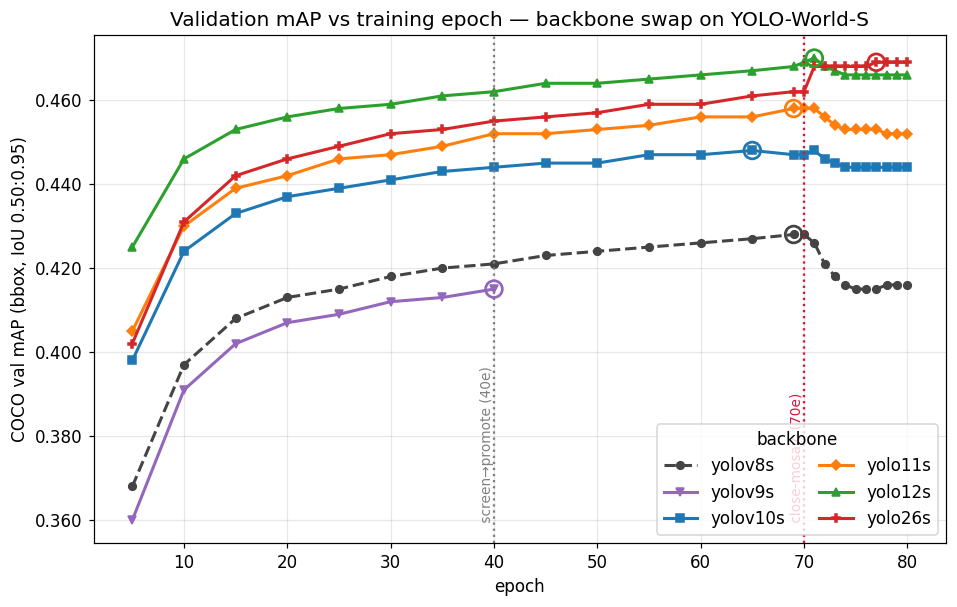

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODELS:
    d = val_df(m)
    ax.plot(d.index, d["mAP"], label=m, lw=2, ms=5, **STYLE[m])
    # mark the best epoch
    be = SUMMARY[m]["best_epoch"]
    ax.scatter([be], [SUMMARY[m]["best_mAP"]], s=120, facecolors="none",
               edgecolors=STYLE[m]["color"], linewidths=1.8, zorder=5)

ax.axvline(40, color="gray", ls=":", lw=1.5)
ax.axvline(70, color="crimson", ls=":", lw=1.5)
ax.text(40, ax.get_ylim()[0] + 0.004, " screen→promote (40e)", color="gray",
        fontsize=9, rotation=90, va="bottom", ha="right")
ax.text(70, ax.get_ylim()[0] + 0.004, " close-mosaic (70e)", color="crimson",
        fontsize=9, rotation=90, va="bottom", ha="right")
ax.set_xlabel("epoch")
ax.set_ylabel("COCO val mAP (bbox, IoU 0.50:0.95)")
ax.set_title("Validation mAP vs training epoch — backbone swap on YOLO-World-S")
ax.legend(title="backbone", ncol=2, loc="upper left")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
savefig(fig, "01_val_map_vs_epoch.png")
plt.show()

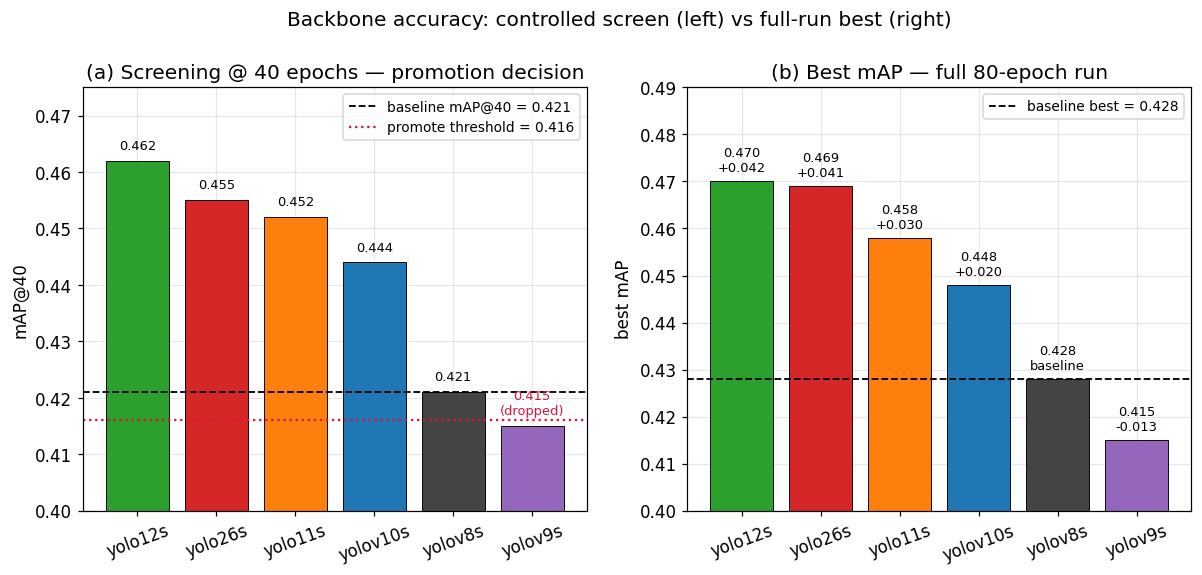

In [6]:
order = results.index.tolist()                      # sorted by best mAP
colors = [STYLE[m]["color"] for m in order]
margin = 0.005
thresh = SUMMARY[BASELINE]["mAP_at40"] - margin

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) screening decision: mAP@40 vs promotion threshold
ax = axes[0]
vals40 = [SUMMARY[m]["mAP_at40"] for m in order]
bars = ax.bar(order, vals40, color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(SUMMARY[BASELINE]["mAP_at40"], color="black", ls="--", lw=1.2,
           label=f"baseline mAP@40 = {SUMMARY[BASELINE]['mAP_at40']:.3f}")
ax.axhline(thresh, color="crimson", ls=":", lw=1.5,
           label=f"promote threshold = {thresh:.3f}")
for b, v, m in zip(bars, vals40, order):
    dropped = SUMMARY[m]["last_epoch"] == 40 and m != BASELINE
    ax.text(b.get_x() + b.get_width() / 2, v + 0.0015,
            f"{v:.3f}" + ("\n(dropped)" if dropped else ""),
            ha="center", va="bottom", fontsize=8.5,
            color="crimson" if dropped else "black")
ax.set_title("(a) Screening @ 40 epochs — promotion decision")
ax.set_ylabel("mAP@40")
ax.set_ylim(0.40, 0.475)
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=20)

# (b) best mAP over the full run
ax = axes[1]
vbest = [SUMMARY[m]["best_mAP"] for m in order]
bars = ax.bar(order, vbest, color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(SUMMARY[BASELINE]["best_mAP"], color="black", ls="--", lw=1.2,
           label=f"baseline best = {SUMMARY[BASELINE]['best_mAP']:.3f}")
for b, m in zip(bars, order):
    v = SUMMARY[m]["best_mAP"]
    dv = v - SUMMARY[BASELINE]["best_mAP"]
    tag = "baseline" if m == BASELINE else f"{dv:+.3f}"
    ax.text(b.get_x() + b.get_width() / 2, v + 0.0015,
            f"{v:.3f}\n{tag}", ha="center", va="bottom", fontsize=8.5)
ax.set_title("(b) Best mAP — full 80-epoch run")
ax.set_ylabel("best mAP")
ax.set_ylim(0.40, 0.49)
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=20)

fig.suptitle("Backbone accuracy: controlled screen (left) vs full-run best (right)", y=1.02)
savefig(fig, "02_map_bars.png")
plt.show()

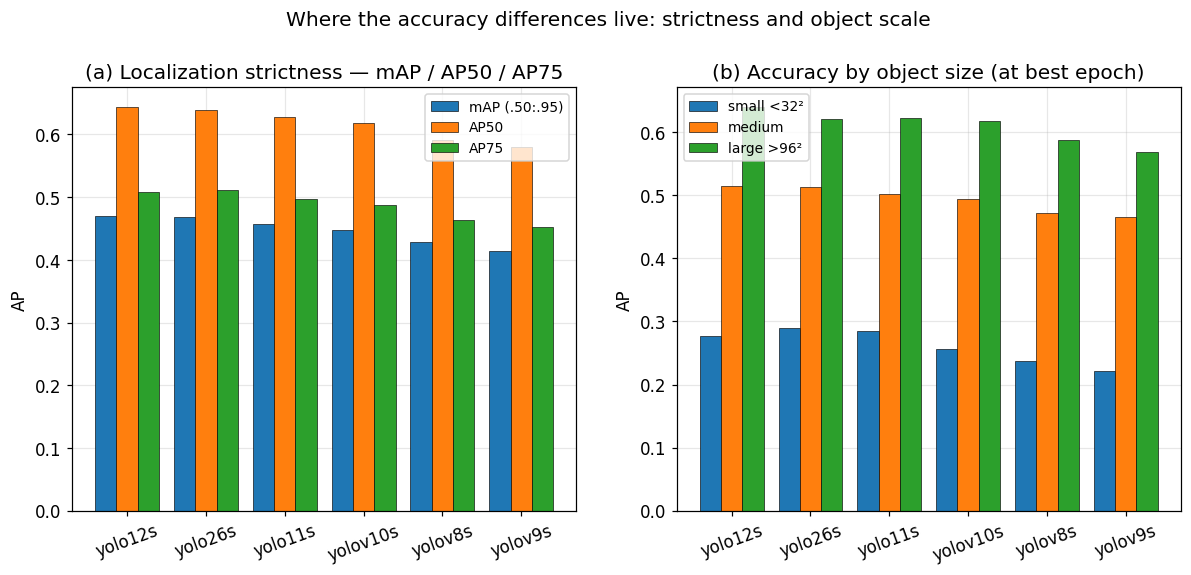

AP-small at best epoch (small objects need the P3 high-res map):
  yolo12s    AP_s=0.277   AP_l=0.639
  yolo26s    AP_s=0.289   AP_l=0.621
  yolo11s    AP_s=0.285   AP_l=0.622
  yolov10s   AP_s=0.256   AP_l=0.618
  yolov8s    AP_s=0.237   AP_l=0.588
  yolov9s    AP_s=0.222   AP_l=0.568


In [7]:
bp = {m: best_point(m) for m in order}
x = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) strictness: mAP vs AP50 vs AP75 (localization quality)
ax = axes[0]
for i, (key, lab) in enumerate([("mAP", "mAP (.50:.95)"), ("mAP_50", "AP50"), ("mAP_75", "AP75")]):
    w = 0.27
    ax.bar(x + (i - 1) * w, [bp[m][key] for m in order], w, label=lab,
           edgecolor="black", linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20)
ax.set_ylabel("AP"); ax.set_title("(a) Localization strictness — mAP / AP50 / AP75")
ax.legend(fontsize=9)

# (b) object scale: AP small / medium / large
ax = axes[1]
for i, (key, lab) in enumerate([("mAP_s", "small <32²"), ("mAP_m", "medium"), ("mAP_l", "large >96²")]):
    w = 0.27
    bars = ax.bar(x + (i - 1) * w, [bp[m][key] for m in order], w, label=lab,
                  edgecolor="black", linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20)
ax.set_ylabel("AP"); ax.set_title("(b) Accuracy by object size (at best epoch)")
ax.legend(fontsize=9)

fig.suptitle("Where the accuracy differences live: strictness and object scale", y=1.02)
savefig(fig, "03_ap_breakdowns.png")
plt.show()

# quick text read-out of the small-object gap, which drives much of the ranking
print("AP-small at best epoch (small objects need the P3 high-res map):")
for m in order:
    print(f"  {m:9s}  AP_s={bp[m]['mAP_s']:.3f}   AP_l={bp[m]['mAP_l']:.3f}")

## 6. Accuracy vs cost — is the extra accuracy "paid for"?

A backbone is only interesting if its accuracy gain is worth its compute. These three scatter plots put
**best mAP** against the three cost axes — vision **params**, **GFLOPs**, and deployment **FPS**. The dashed
grey lines mark the `yolov8s` baseline; the **top-left** region (params/FLOPs plots) and **top-right** region
(FPS plot) is where you want to be. Points on the upper-left/right hull form the **Pareto frontier**
(no other backbone is both more accurate *and* cheaper/faster).

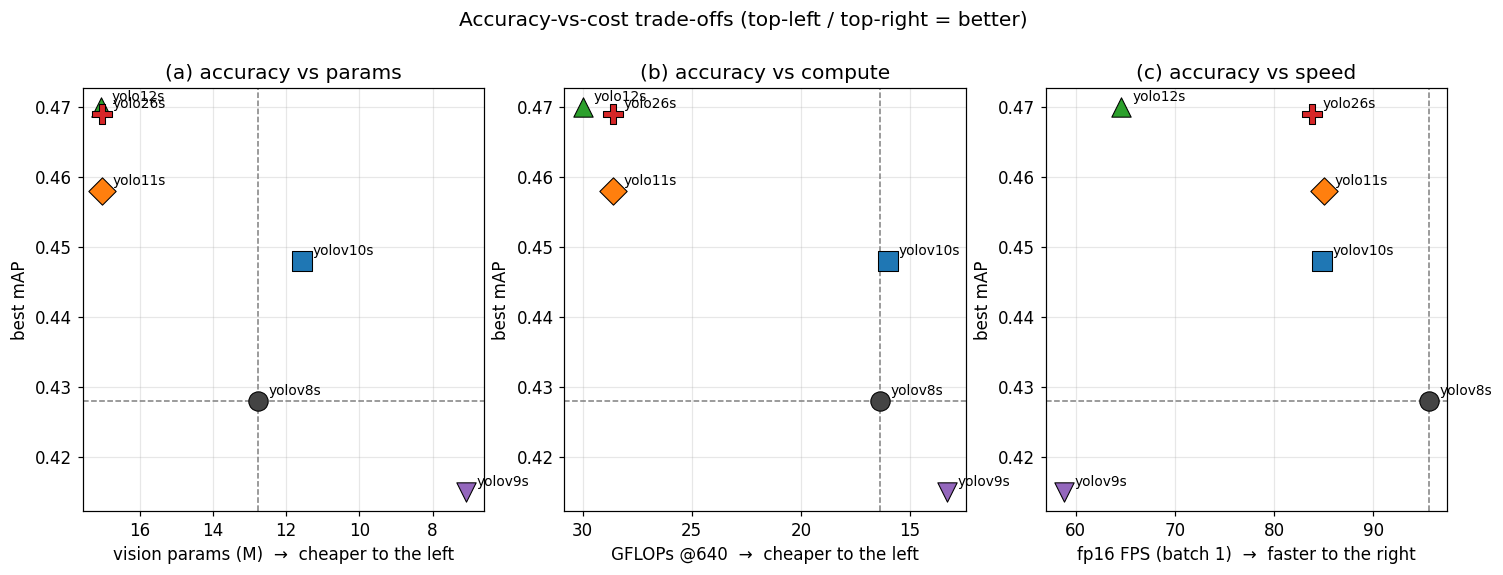

,best mAP,mAP / Mparam,mAP / GFLOP,fp16 FPS
yolov9s,0.415,0.059,0.031,58.800
yolov10s,0.448,0.039,0.028,84.800
yolov8s,0.428,0.034,0.026,95.600
yolo26s,0.469,0.028,0.016,83.800
yolo11s,0.458,0.027,0.016,85.000
yolo12s,0.470,0.028,0.016,64.600


In [8]:
def scatter(ax, xkey, xlabel, invert=False):
    for m in MODELS:
        xy = (SPEED[m][xkey], SUMMARY[m]["best_mAP"])
        ax.scatter(*xy, s=160, color=STYLE[m]["color"],
                   edgecolor="black", linewidth=0.7, zorder=3,
                   marker=STYLE[m]["marker"])
        ax.annotate(m, xy, textcoords="offset points", xytext=(7, 4), fontsize=9)
    ax.axhline(SUMMARY[BASELINE]["best_mAP"], color="gray", ls="--", lw=1)
    ax.axvline(SPEED[BASELINE][xkey], color="gray", ls="--", lw=1)
    ax.set_xlabel(xlabel); ax.set_ylabel("best mAP")
    if invert:
        ax.invert_xaxis()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scatter(axes[0], "params_vision_M", "vision params (M)  →  cheaper to the left", invert=True)
axes[0].set_title("(a) accuracy vs params")
scatter(axes[1], "gflops_vision", "GFLOPs @640  →  cheaper to the left", invert=True)
axes[1].set_title("(b) accuracy vs compute")
scatter(axes[2], "fps_fp16", "fp16 FPS (batch 1)  →  faster to the right")
axes[2].set_title("(c) accuracy vs speed")
fig.suptitle("Accuracy-vs-cost trade-offs (top-left / top-right = better)", y=1.02)
savefig(fig, "04_tradeoffs.png")
plt.show()

# mAP per million vision params and per GFLOP — the "efficiency" of each backbone
eff = pd.DataFrame({
    "best mAP": [SUMMARY[m]["best_mAP"] for m in MODELS],
    "mAP / Mparam": [SUMMARY[m]["best_mAP"] / SPEED[m]["params_vision_M"] for m in MODELS],
    "mAP / GFLOP": [SUMMARY[m]["best_mAP"] / SPEED[m]["gflops_vision"] for m in MODELS],
    "fp16 FPS": [SPEED[m]["fps_fp16"] for m in MODELS],
}, index=MODELS).sort_values("mAP / GFLOP", ascending=False)
eff.round(4)

## 7. Training dynamics

These come from the raw per-iteration logs (`scalars.json`), aggregated to per-epoch means. They explain
*how* each run got to its accuracy and expose two recipe effects:

- **The shared LR schedule** (linear warm-up → linear decay to `1% × base_lr`) is identical for everyone,
  confirming the screen is a true prefix of the 80e run.
- **The close-mosaic switch at epoch 70** removes mosaic/mixup/copy-paste. The training data suddenly gets
  "easier", so **training loss drops sharply** at epoch 71 — but whether *validation* mAP improves depends on
  the backbone (see §8).

> Note: `loss_cls` here is large in absolute terms because YOLO-World's contrastive classification loss is
> summed over many text-vs-region comparisons; only its **trend** is meaningful, not its absolute scale.

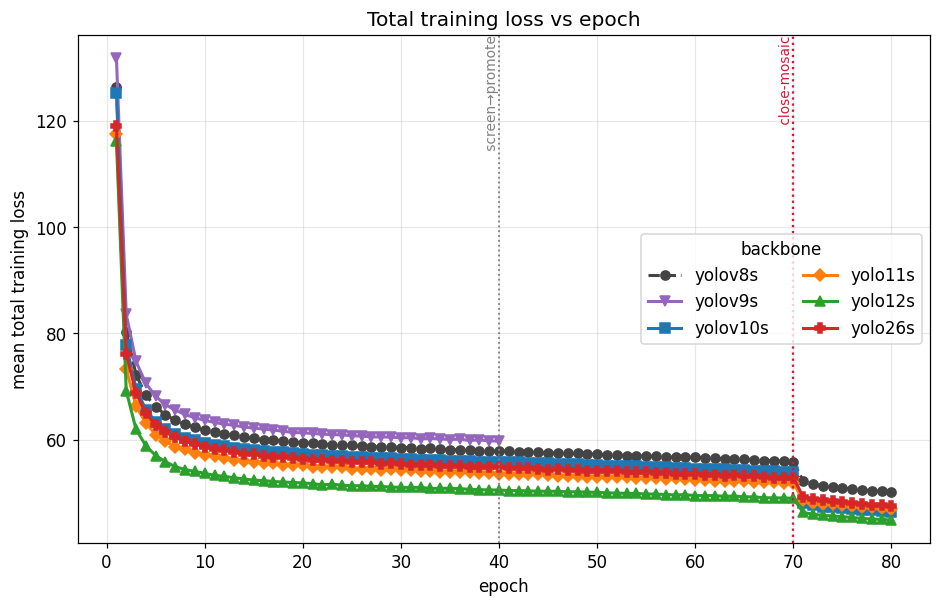

In [9]:
# Total training loss vs epoch (per-epoch mean), with the close-mosaic marker.
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODELS:
    d = TRAIN[m]
    if d.empty:
        continue
    ax.plot(d.index, d["loss"], label=m, lw=2, **STYLE[m])
ax.axvline(70, color="crimson", ls=":", lw=1.5)
ax.text(70, ax.get_ylim()[1], " close-mosaic", color="crimson", fontsize=9,
        rotation=90, va="top", ha="right")
ax.axvline(40, color="gray", ls=":", lw=1.2)
ax.text(40, ax.get_ylim()[1], " screen→promote", color="gray", fontsize=9,
        rotation=90, va="top", ha="right")
ax.set_xlabel("epoch"); ax.set_ylabel("mean total training loss")
ax.set_title("Total training loss vs epoch")
ax.legend(title="backbone", ncol=2)
savefig(fig, "05_train_loss.png")
plt.show()

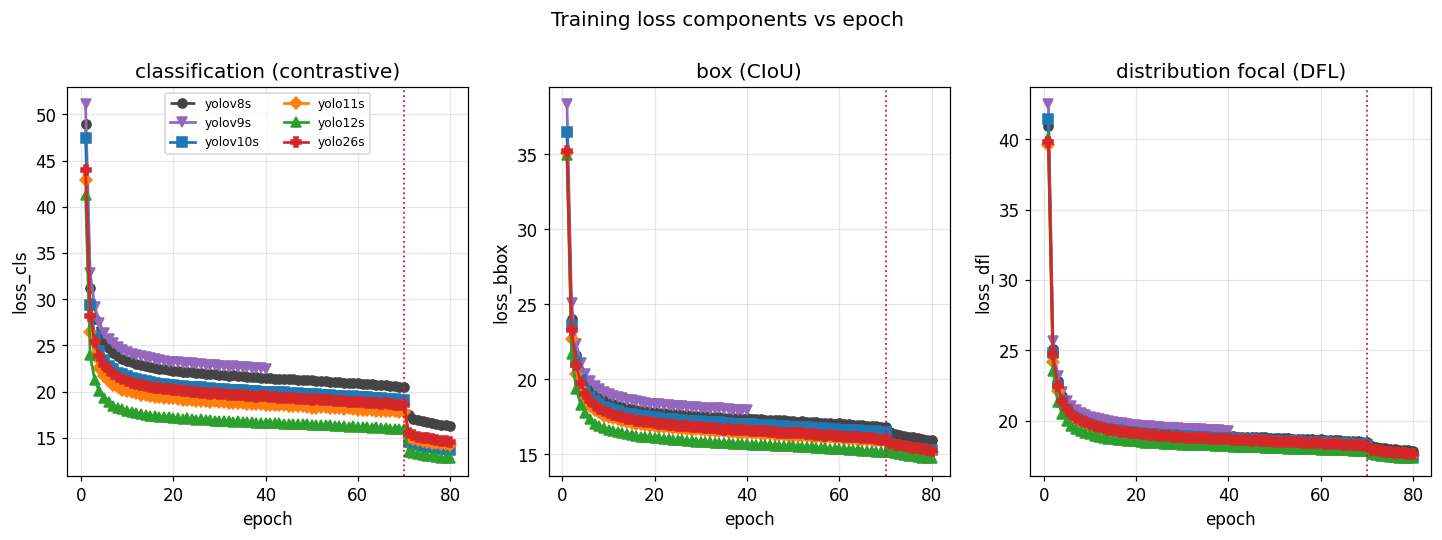

In [10]:
# Loss components (cls / bbox / dfl) as small multiples.
comps = [("loss_cls", "classification (contrastive)"),
         ("loss_bbox", "box (CIoU)"),
         ("loss_dfl", "distribution focal (DFL)")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (key, title) in zip(axes, comps):
    for m in MODELS:
        d = TRAIN[m]
        if d.empty:
            continue
        ax.plot(d.index, d[key], label=m, lw=1.8, **STYLE[m])
    ax.axvline(70, color="crimson", ls=":", lw=1.2)
    ax.set_xlabel("epoch"); ax.set_ylabel(key); ax.set_title(title)
axes[0].legend(fontsize=8, ncol=2)
fig.suptitle("Training loss components vs epoch", y=1.03)
savefig(fig, "06_loss_components.png")
plt.show()

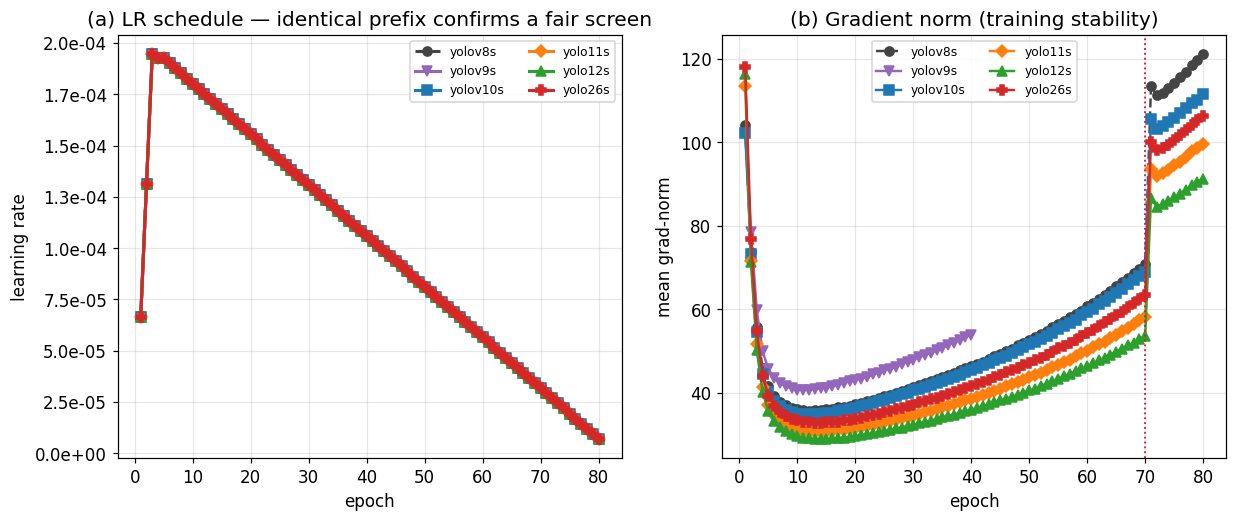

In [11]:
# LR schedule (shared) and gradient norm (stability).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for m in MODELS:
    d = TRAIN[m]
    if d.empty:
        continue
    ax.plot(d.index, d["lr"], label=m, lw=2, **STYLE[m])
ax.set_xlabel("epoch"); ax.set_ylabel("learning rate")
ax.set_title("(a) LR schedule — identical prefix confirms a fair screen")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1e"))
ax.legend(fontsize=8, ncol=2)

ax = axes[1]
for m in MODELS:
    d = TRAIN[m]
    if d.empty:
        continue
    ax.plot(d.index, d["grad_norm"], label=m, lw=1.6, **STYLE[m])
ax.axvline(70, color="crimson", ls=":", lw=1.2)
ax.set_xlabel("epoch"); ax.set_ylabel("mean grad-norm")
ax.set_title("(b) Gradient norm (training stability)")
ax.legend(fontsize=8, ncol=2)
savefig(fig, "07_lr_gradnorm.png")
plt.show()

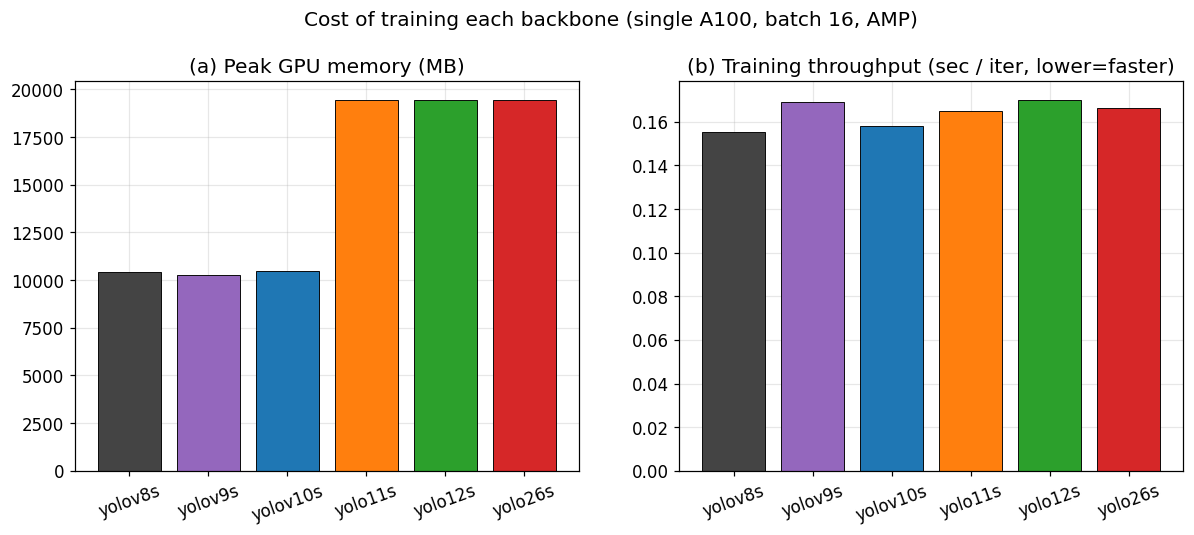

,peak_mem_MB,sec/iter,min/epoch,epochs_trained,approx_GPU_hours
backbone,,,,,
yolov8s,10417,0.155,19.100,80,25.400
yolov9s,10252,0.169,20.800,40,13.900
yolov10s,10469,0.158,19.500,80,26.000
yolo11s,19446,0.165,20.300,80,27.100
yolo12s,19442,0.170,21.000,80,28.000
yolo26s,19446,0.166,20.400,80,27.200


In [12]:
# Training-cost: peak GPU memory and throughput (sec/iter), from the logs.
ITERS_PER_EPOCH = 118287 / 16   # COCO train images / batch size

cost_rows = []
for m in MODELS:
    d = TRAIN[m]
    if d.empty:
        continue
    sec_it = d["sec_per_iter"].median()
    n_ep = int(d.index.max())
    cost_rows.append({
        "backbone": m,
        "peak_mem_MB": int(d["mem_MB"].max()),
        "sec/iter": round(sec_it, 3),
        "min/epoch": round(sec_it * ITERS_PER_EPOCH / 60, 1),
        "epochs_trained": n_ep,
        "approx_GPU_hours": round(sec_it * ITERS_PER_EPOCH * n_ep / 3600, 1),
    })
cost = pd.DataFrame(cost_rows).set_index("backbone")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
mods = cost.index.tolist()
cols = [STYLE[m]["color"] for m in mods]
axes[0].bar(mods, cost["peak_mem_MB"], color=cols, edgecolor="black", linewidth=0.6)
axes[0].set_title("(a) Peak GPU memory (MB)"); axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(mods, cost["sec/iter"], color=cols, edgecolor="black", linewidth=0.6)
axes[1].set_title("(b) Training throughput (sec / iter, lower=faster)")
axes[1].tick_params(axis="x", rotation=20)
fig.suptitle("Cost of training each backbone (single A100, batch 16, AMP)", y=1.02)
savefig(fig, "08_train_cost.png")
plt.show()
cost

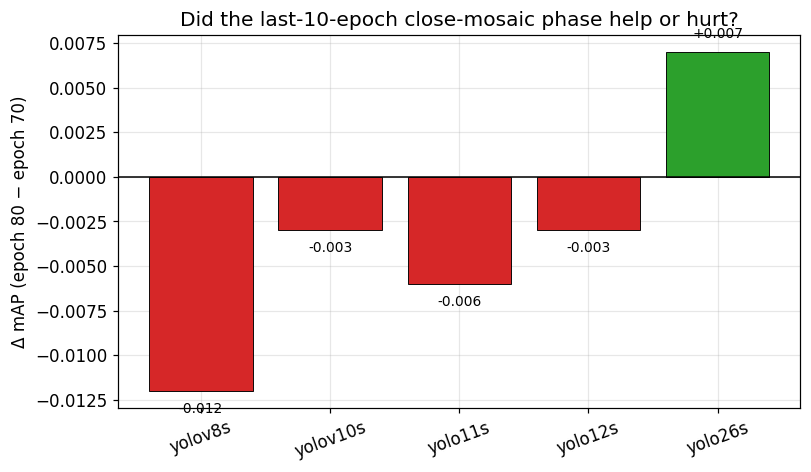

,mAP@70 (pre),mAP@80 (final),best mAP,best ep,Δ final-70,close-mosaic verdict
backbone,,,,,,
yolov8s,0.428,0.416,0.428,69,-0.012,hurt
yolov10s,0.447,0.444,0.448,65,-0.003,hurt
yolo11s,0.458,0.452,0.458,69,-0.006,hurt
yolo12s,0.469,0.466,0.470,71,-0.003,hurt
yolo26s,0.462,0.469,0.469,77,0.007,helped


In [13]:
# Quantify the close-mosaic effect: mAP just before the switch (ep70) vs the final epoch (ep80).
def map_at(model, epoch):
    d = val_df(model)
    return float(d.loc[epoch, "mAP"]) if epoch in d.index else np.nan

cm_rows = []
for m in MODELS:
    if SUMMARY[m]["last_epoch"] < 80:
        continue
    m70, m80 = map_at(m, 70), map_at(m, 80)
    cm_rows.append({
        "backbone": m,
        "mAP@70 (pre)": m70,
        "mAP@80 (final)": m80,
        "best mAP": SUMMARY[m]["best_mAP"],
        "best ep": SUMMARY[m]["best_epoch"],
        "Δ final-70": round(m80 - m70, 3),
        "close-mosaic verdict": ("helped" if m80 - m70 > 0.001 else
                                  "hurt" if m80 - m70 < -0.001 else "neutral"),
    })
close_mosaic = pd.DataFrame(cm_rows).set_index("backbone")

fig, ax = plt.subplots(figsize=(8, 4.4))
vals = close_mosaic["Δ final-70"]
bars = ax.bar(close_mosaic.index, vals,
              color=["#2ca02c" if v > 0 else "#d62728" for v in vals],
              edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", lw=1)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + (0.0006 if v >= 0 else -0.0006),
            f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
ax.set_ylabel("Δ mAP (epoch 80 − epoch 70)")
ax.set_title("Did the last-10-epoch close-mosaic phase help or hurt?")
ax.tick_params(axis="x", rotation=20)
savefig(fig, "09_close_mosaic_effect.png")
plt.show()
close_mosaic

## 8. Why these outcomes happened

### 8.1 The screen perfectly predicted the final ranking
The order at epoch 40 (`yolo12s > yolo26s > yolo11s > yolov10s > yolov8s > yolov9s`) is **exactly** the order
of `best mAP` at epoch 80. This is the strongest evidence that the *screen→promote* protocol is sound: because
epochs 1–40 are a byte-for-byte prefix of the 80e schedule (same LR curve in §7a, same augmentation), `mAP@40`
is an unbiased early read on a backbone's ceiling. No promoted backbone changed rank during the second half.

### 8.2 Newer backbones win mostly on **small objects** (the P3 story)
Look at §3b and the AP-small read-out. The three top backbones (`yolo11s`, `yolo12s`, `yolo26s`) all expose a
**256-channel P3** feature map, versus **128** for `yolov8s`/`yolov10s` and `yolov9s`. P3 (stride 8) is the
high-resolution map that small-object detection depends on, and it is exactly where the gains concentrate:
AP-small climbs from **0.237** (yolov8s) to **0.285 / 0.277 / 0.289** (11s/12s/26s). The large-object AP gap is
much smaller. So the headline mAP improvement is largely "the newer backbones see small objects better",
enabled by a wider P3 feeding the text-fusion neck — plus their stronger blocks (C2PSA attention in YOLO11,
area-attention in YOLO12/26) that give richer features at equal resolution.

### 8.3 `yolov10s` is the quiet Pareto win
`yolov10s` reaches **0.448** best mAP (**+0.020** over baseline) with **fewer vision params (11.57 M vs 12.76 M)**,
**fewer GFLOPs (16.0 vs 16.4)**, and essentially the same speed (84.8 vs 95.6 FPS). That is a *strict* improvement
on the params/FLOPs axes — it is more accurate **and** cheaper to compute than the YOLOv8 baseline. Its NMS-free,
C2fCIB design is simply a better backbone than v8 at the same width class. It only keeps a 128-channel P3, which
is why it can't reach the 11/12/26 tier on small objects.

### 8.4 `yolov9s` is the only regression — and was correctly dropped
`yolov9s` has the **fewest params (7.09 M) and lowest GFLOPs (13.3)**, yet posts the **lowest mAP (0.415,
−0.006 vs baseline @40)**. Two reasons: (1) its **P4/P5 channels are narrow (192/256 vs 256/512)**, which starves
the text-guided neck of channel capacity right where mid/large semantics are fused with text; (2) GELAN's highly
fragmented, many-small-ops structure is **memory-bound on GPU**, so despite the lowest FLOPs it is also the
**slowest (58.8 fp16 FPS)**. Low accuracy *and* low speed = no reason to promote; the funnel dropped it at 40e.

### 8.5 FLOPs ≠ speed (why the FPS ranking disagrees)
`yolov9s` (13.3 GFLOPs) is slower than `yolo11s`/`yolo26s` (28.6 GFLOPs). FLOPs count multiply-adds; **FPS is set
by latency and memory-access patterns**. Fragmented blocks (GELAN) and bandwidth-heavy attention (`yolo12s`'s
area-attention → 64.6 FPS, the slowest promoted) hurt wall-clock far more than their FLOPs suggest. `yolo26s` is
the counter-example: it adds attention but is **latency-tuned**, so it nearly matches `yolo11s` speed (83.8 vs
85.0 FPS) at meaningfully higher accuracy.

### 8.6 Close-mosaic helped exactly one backbone
Conventional wisdom says turning off mosaic for the last epochs *raises* mAP. Here (§7 close-mosaic chart) it
only helped **`yolo26s` (+0.007, its best epoch is 77)**; it was **neutral-to-harmful for everyone else**
(baseline −0.012, yolo11s −0.006, yolov10s/yolo12s ≈ −0.003). Likely cause: with a **neck/head trained from
scratch on COCO-only**, most variants have already saturated by ~epoch 65–70, and the abrupt distribution shift
to clean images mainly lets EMA drift off the earlier optimum — so `save_best` correctly keeps the pre-switch
checkpoint (epoch 65–71) for them. `yolo26s` was still improving at the switch, so it banked the gain.

### 8.7 Caveats before over-reading the table
- **Single run, no seeds.** Differences of **~0.001–0.002 mAP** (e.g. `yolo12s` 0.470 vs `yolo26s` 0.469) are
  within run-to-run noise and should be treated as a tie.
- **COCO-only, neck/head from scratch** → absolute mAP (~0.42–0.47) is well below the ~45.7 of fully-pretrained
  YOLO-World-S. Only the **relative** backbone ranking transfers.
- **FPS is batch-1 with cached text** on an A100; relative speed should hold but absolute numbers are
  hardware/regime specific.

## 9. Conclusions &amp; recommendations

**Swapping YOLO-World-S's YOLOv8 backbone for a newer generation helps — substantially — and the gain is real
because the backbone was the only variable.** Every backbone newer than v8 (except v9) beat the baseline.

**Pick by deployment goal:**

| If you want… | Choose | Why |
|---|---|---|
| **Best accuracy/speed balance** (recommended default) | **`yolo26s`** | best mAP **0.469** (≈ tied with yolo12s) but **83.8 FPS** — ~30% faster than yolo12s; also the only one that *gains* from close-mosaic |
| **Maximum accuracy**, speed secondary | **`yolo12s`** | top mAP **0.470**, but slowest promoted (**64.6 FPS**, 30.0 GFLOPs) — area-attention is expensive |
| **Lightweight / efficiency** (edge, strict FLOP/param budget) | **`yolov10s`** | **+0.020** mAP over baseline with **fewer params & FLOPs** than v8 — a strict Pareto win |
| **Balanced, conservative upgrade** | **`yolo11s`** | **0.458** mAP at the same cost class as yolo26s; a safe, well-understood step up |
| **Drop-in larger raw accuracy at v8 cost class** | not `yolov9s` | the only regression; narrow P4/P5 + memory-bound GELAN → both slower and less accurate |

**Headline numbers (COCO val2017 bbox):**
- Accuracy ladder (best mAP): **yolo12s 0.470 ≥ yolo26s 0.469 > yolo11s 0.458 > yolov10s 0.448 > yolov8s 0.428 > yolov9s 0.415**.
- The biggest single lever is **small-object AP**, unlocked by the wider **P3 (256-ch)** backbones.
- The newer-generation backbones cost more (17 M params, ~28–30 GFLOPs for 11/12/26) — except **yolov10s**, which improves on the baseline while getting *cheaper*.

**Suggested next steps** (to harden these findings): repeat the top 2–3 with **2–3 seeds** to put error bars on
the ~0.001 gaps; try the **`m`/`l`** scales to see if the ranking holds with capacity; and, if absolute mAP
matters, add a short **Objects365/GoldG pretraining** stage before the COCO finetune.

---
*The final code cell below recaps the saved artifacts (summary CSV + all figures) so this analysis is reproducible.*

In [14]:
# Recap of saved artifacts.
print("Saved analysis artifacts under results/:\n")
print(f"  table  : {(ROOT/'results/analysis/backbone_swap_summary.csv').relative_to(ROOT)}")
for png in sorted(FIGDIR.glob("*.png")):
    print(f"  figure : {png.relative_to(ROOT)}")

print("\nFinal ranking by best mAP (COCO val2017 bbox):")
for m in results.index:
    tag = "  <- baseline" if m == BASELINE else ""
    print(f"  {m:9s}  best mAP={SUMMARY[m]['best_mAP']:.3f}  "
          f"@40={SUMMARY[m]['mAP_at40']:.3f}  "
          f"fp16 FPS={SPEED[m]['fps_fp16']:.1f}{tag}")

Saved analysis artifacts under results/:

  table  : results/analysis/backbone_swap_summary.csv
  figure : results/analysis/figures/01_val_map_vs_epoch.png
  figure : results/analysis/figures/02_map_bars.png
  figure : results/analysis/figures/03_ap_breakdowns.png
  figure : results/analysis/figures/04_tradeoffs.png
  figure : results/analysis/figures/05_train_loss.png
  figure : results/analysis/figures/06_loss_components.png
  figure : results/analysis/figures/07_lr_gradnorm.png
  figure : results/analysis/figures/08_train_cost.png
  figure : results/analysis/figures/09_close_mosaic_effect.png

Final ranking by best mAP (COCO val2017 bbox):
  yolo12s    best mAP=0.470  @40=0.462  fp16 FPS=64.6
  yolo26s    best mAP=0.469  @40=0.455  fp16 FPS=83.8
  yolo11s    best mAP=0.458  @40=0.452  fp16 FPS=85.0
  yolov10s   best mAP=0.448  @40=0.444  fp16 FPS=84.8
  yolov8s    best mAP=0.428  @40=0.421  fp16 FPS=95.6  <- baseline
  yolov9s    best mAP=0.415  @40=0.415  fp16 FPS=58.8
